In [89]:
import numpy as np
import pandas as pd

In [90]:
data=pd.read_csv(r'placement.csv')
data.sample(5)

,Unnamed: 0,cgpa,iq,placement
66,66,6.9,96.0,1
63,63,6.3,128.0,1
76,76,4.9,155.0,0
71,71,6.1,132.0,1
37,37,8.1,149.0,1


In [93]:
data.set_index('Unnamed: 0',inplace=True)
data.index.name=None
data.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [94]:
data.shape

(100, 3)

In [95]:
data.describe()

,cgpa,iq,placement
count,100.000000,100.000000,100.000000
mean,5.991000,123.580000,0.500000
std,1.143634,39.944198,0.502519
min,3.300000,37.000000,0.000000
25%,5.075000,101.500000,0.000000
50%,6.000000,127.500000,0.500000
75%,6.900000,149.000000,1.000000
max,8.500000,233.000000,1.000000


In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.1 KB


In [97]:
data.corr()

,cgpa,iq,placement
cgpa,1.000000,-0.098791,0.821688
iq,-0.098791,1.000000,-0.083031
placement,0.821688,-0.083031,1.000000


In [98]:
data.skew()

cgpa        -0.000695
iq           0.018096
placement    0.000000
dtype: float64

In [99]:
data.kurt()

cgpa        -0.638795
iq           0.080032
placement   -2.041237
dtype: float64

In [100]:
min_cgpa=data['cgpa'].quantile(0.25)-1.5*(data['cgpa'].quantile(0.75)-data['cgpa'].quantile(0.25))
max_cgpa=data['cgpa'].quantile(0.25)+1.5*(data['cgpa'].quantile(0.75)-data['cgpa'].quantile(0.25))

In [101]:
min_cgpa,max_cgpa

(np.float64(2.3374999999999977), np.float64(7.812500000000001))

In [102]:
min_package=data['placement'].quantile(0.25)-1.5*(data['placement'].quantile(0.75)-data['placement'].quantile(0.25))
max_package=data['placement'].quantile(0.25)+1.5*(data['placement'].quantile(0.75)-data['placement'].quantile(0.25))

In [103]:
min_package,max_package

(np.float64(-1.5), np.float64(1.5))

In [104]:
min_iq=data['iq'].quantile(0.25)-1.5*(data['iq'].quantile(0.75)-data['iq'].quantile(0.25))
max_iq=data['iq'].quantile(0.25)+1.5*(data['iq'].quantile(0.75)-data['iq'].quantile(0.25))

In [105]:
min_iq,max_iq

(np.float64(30.25), np.float64(172.75))

In [106]:
data.isna().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [107]:
data.duplicated().sum()

np.int64(0)

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

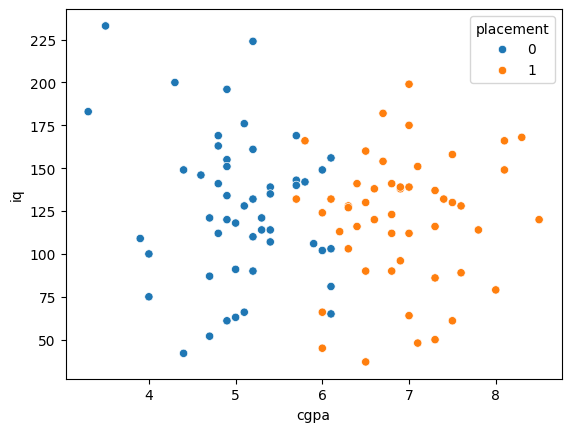

In [121]:
sns.scatterplot(data=data,x='cgpa',y='iq',hue='placement')
plt.show()

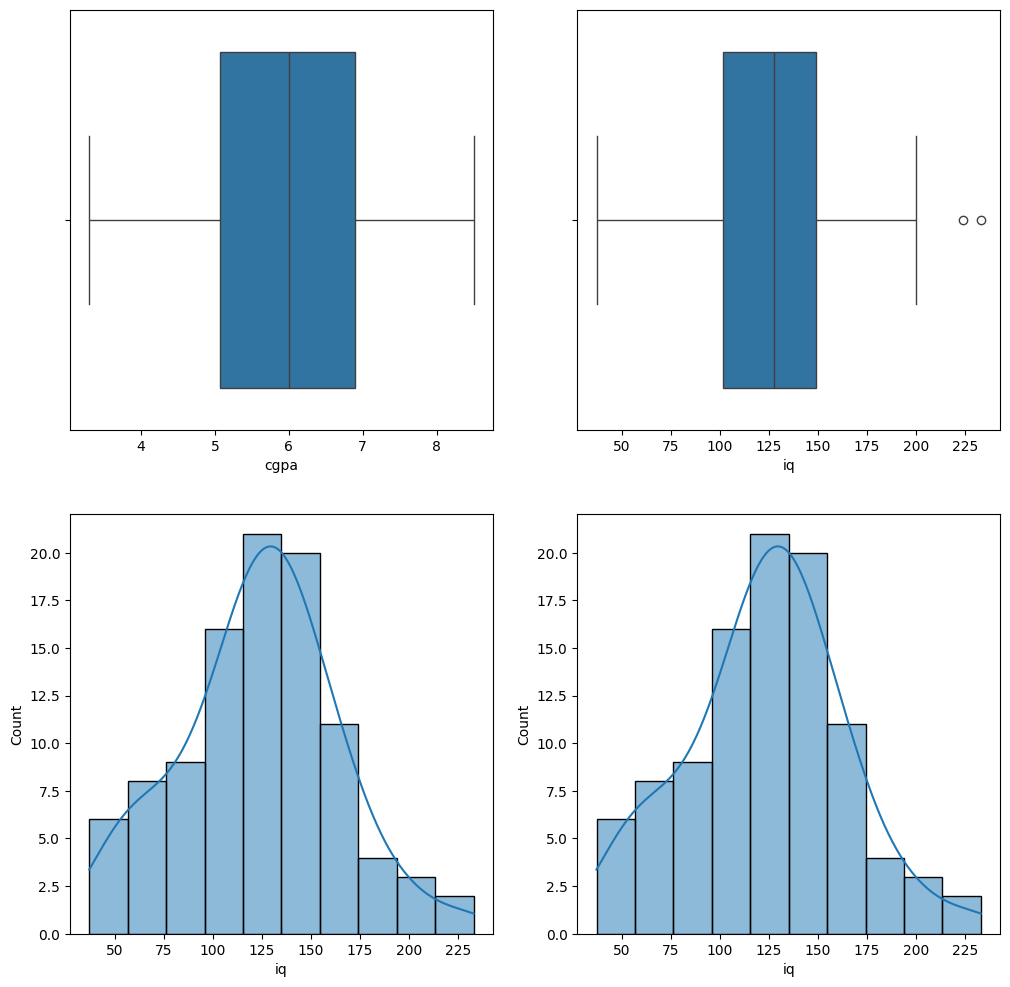

In [137]:
fig=plt.figure(figsize=(12,12))

ax1=fig.add_subplot(221)
sns.boxplot(data=data,x='cgpa',ax=ax1)

ax2=fig.add_subplot(222)
sns.boxplot(data=data,x='iq',ax=ax2)

ax3=fig.add_subplot(223)
sns.histplot(data=data,x='iq',kde=True,ax=ax3)

ax4=fig.add_subplot(224)
sns.histplot(data=data,x='iq',kde=True,ax=ax4)

plt.show()

In [129]:
data['placement'].value_counts()

placement
1    50
0    50
Name: count, dtype: int64

In [139]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score,accuracy_score

In [140]:
X_train,X_test,y_train,y_test=train_test_split(data.drop(columns=['placement']),data[['placement']],test_size=0.2,random_state=42)

In [141]:
tr=ColumnTransformer(transformers=[
('tr1',MinMaxScaler(),['iq','cgpa'])
],remainder="passthrough")

X_train_trans=tr.fit_transform(X_train)
X_test_trans=tr.transform(X_test)

In [142]:
lr1=LogisticRegression()
lr1.fit(X_train_trans,y_train)

y_pred1=lr1.predict(X_test_trans)

score1=accuracy_score(y_test,y_pred1)
# lr.score(X_test_trans,y_test)
print(score1)

0.85


C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


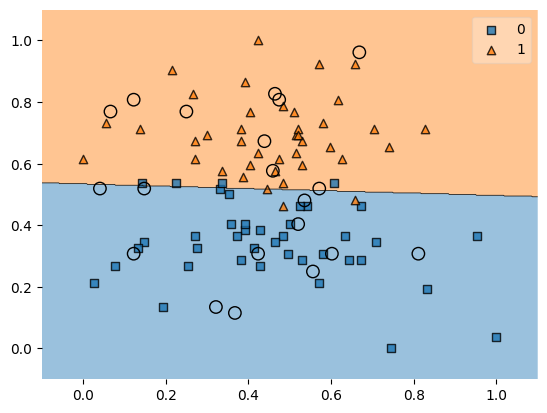

In [171]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train_trans,y_train.values.ravel(), clf=lr1,X_highlight=X_test_trans,zoom_factor=10)
plt.show()

In [146]:
np.mean(cross_val_score(LogisticRegression(),data.drop(columns=['placement']),data[['placement']],cv=5,scoring='accuracy'))

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

np.float64(0.9)

In [147]:
# without scalling

lr2=LogisticRegression()
lr2.fit(X_train,y_train)

y_pred2=lr2.predict(X_test)

score2=accuracy_score(y_test,y_pred1)
# lr.score(X_test_trans,y_test)
print(score2)

0.85


C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [173]:
import pickle
pickle.dump(lr1,open('model.pkl','wb'))